<a href="https://colab.research.google.com/github/mptorpo/integracion_prospectiva_y_datos/blob/main/Reto_5_Miguel_Pimiento_Restrepo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Riesgo Operacional en Canales Electrónicos**

- Miguel Pimiento Restrepo
- Epik ID: 1000293648

Como analistas de riesgos de una entidad financiera, se recibe la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en los canales electrónicos (App Móvil, Sucursal Virtual, Cajeros) entre 2009 y 2011. La misión es transformar los datos crudos en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales.

Para ello se aplica la metodología de Riesgo Operacional, construyendo de manera integrada las matrices de Frecuencia, Severidad y Pérdidas Agregadas, usando el método de clusterización K-Means (con la misma función desarrollada en clase). Posteriormente se construyen las matrices de Impacto y Gestión, se estima la Pérdida Esperada (PE) y el Operational Value at Risk (OpVaR) al 99,9% de confianza, comparando los escenarios de Riesgo Inherente (sin gestión) y Riesgo Residual (con gestión).

Finalmente, se desarrolla una herramienta de auditoría que permite consultar dinámicamente cualquier celda de la matriz de pérdidas y desplegar el listado de eventos que la componen.

**Variables:**
- Fechas: Fecha en la que se registró el evento de falla tecnológica en los canales electrónicos (App Móvil, Sucursal Virtual, Cajeros). Cubre el periodo del 1 de enero de 2009 al 17 de diciembre de 2011
- Transacciones Diarias: Número total de transacciones procesadas por la entidad financiera en el día. Representa el volumen operativo de los canales electrónicos y sirve como denominador para entender la magnitud relativa de las fallas.
- Valor Transado (millones): Monto total en millones de USD movilizado por las transacciones del día. Refleja la exposición económica diaria de la operación de los canales electrónicos.
- Transacciones Fallidas: Número de transacciones que no se completaron exitosamente debido a fallas tecnológicas. Esta variable se utiliza como medida de Frecuencia (Xf) en el modelo de Riesgo Operacional, ya que cuantifica el conteo de ocurrencias del evento de riesgo.
- Valor Generado Promedio (Millones): Valor económico promedio asociado a cada transacción fallida, expresado en millones de USD. Esta variable se utiliza como medida de Severidad (Xs) en el modelo, ya que representa la magnitud del daño financiero por evento.
- Descripción Evento: Texto cualitativo que describe la naturaleza de la falla ocurrida ese día. Existen 5 categorías que se corresponden con los niveles de la matriz de Riesgos: errores visuales menores (Bajo), errores en la interfaz de usuario (Medio), degradación del rendimiento por varias horas (Alto), degradación severa por más de 12 horas (Crítico) y caída total del sistema por más de 24 horas (Catastrófico).

#**Código**

0. Se procede con la carga de las librerias de trabajo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Se define la funcion de clusterizacion (K-Means con 5 semillas: Improbable, Posible, Ocasional, Probable, Frecuente).

In [ ]:
def clusterizacion(Xi):

# Proceso de clústerización
  XC = np.random.choice(Xi, size = 5)
  XC = np.sort(XC) # Semillas de la cústerización (Improbable, Posible, Ocasional, Probable, Frecuente)
  nc = np.zeros((len(Xi),1))

  for k in range(len(Xi)): # El primer dato en primera semilla
    d = np.abs(XC-Xi[k]) # Distancia de un dato a cada semilla
    nc[k] = np.argmin(d)
    nc2 = np.int32(nc[k])
    XC[nc2,] = (XC[nc2,]+Xi[k])/2

  return XC,nc

1. Se cargan los archivos de trabajo

In [ ]:
nxl = '/content/drive/MyDrive/Colab Notebooks/5. Riesgo Operacional FallasTecnológicas.xlsx'

# Hoja principal con los eventos diarios (header en la fila 1)
XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas', header=1)
XDB.head()

,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [ ]:
np.random.seed(42)

# Frecuencia: Transacciones Fallidas (numero de eventos por dia)
Xf = np.array(XDB['Transacciones Fallidas'])
XCf, ncf = clusterizacion(Xf)

# Severidad: Valor Generado Promedio en Millones (perdida promedio por evento)
Xs = np.array(XDB['Valor Generado Promedio (Millones)'])
XCs, ncs = clusterizacion(Xs)

# Distribucion de Perdidas Agregadas (LDA = Frecuencia x Severidad)
LDA = Xf*Xs
XClda, nclda = clusterizacion(LDA)

# Creamos un dataframe consolidado de trabajo
df = pd.DataFrame(np.column_stack((Xf, ncf, Xs, ncs, LDA, nclda)))
df.columns = ['Freq', 'Nivel_f', 'Sev.', 'Nivel_S', 'LDA', 'Nivel_LDA']
df['Descripcion'] = XDB['Descripción Evento'].values
df['Fecha'] = XDB['Fechas'].values
df.head()

,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Descripcion,Fecha
0,1.0,0.0,0.5374,0.0,0.5374,0.0,"Errores visuales menores, problemas de usabili...",2009-01-01
1,4.0,0.0,1.1978,2.0,4.7912,2.0,"Errores en la interfaz de usuario, fallas en f...",2009-01-02
2,5.0,1.0,0.4269,0.0,2.1345,1.0,"Errores visuales menores, problemas de usabili...",2009-01-03
3,6.0,1.0,1.0814,1.0,6.4884,3.0,"Errores en la interfaz de usuario, fallas en f...",2009-01-04
4,7.0,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f...",2009-01-05


2. Procedemos con la construccion de las matrices de eventos de riesgo (Frecuencia y Severidad)

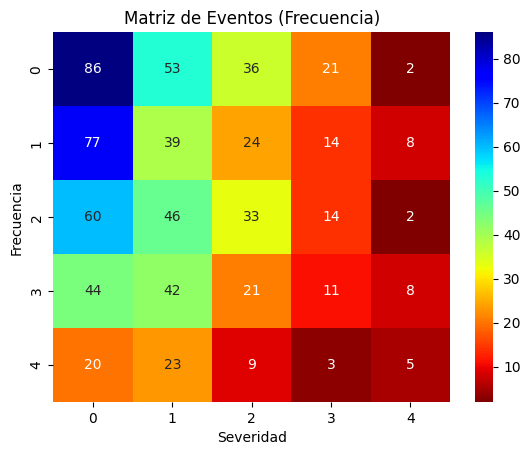

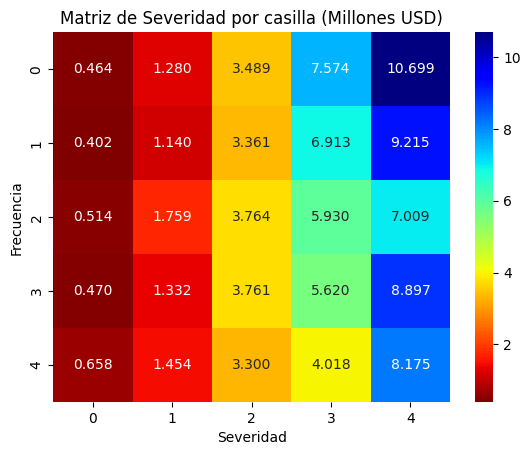

In [ ]:
MEf = np.zeros((5,5)) # Cuantos eventos cayeron en cada categoria de frecuencia x severidad
MEs = np.zeros((5,5)) # Severidad promedio por casilla (en millones)

for k in range(len(Xf)):
   nf = np.int32(df.iloc[k,1]) # Fila de frecuencia
   nc = np.int32(df.iloc[k,3]) # Columna de severidad
   MEf[nf,nc] = MEf[nf,nc] + 1                    # Conteo de eventos
   MEs[nf,nc] = (MEs[nf,nc] + Xs[k])/2            # Severidad promedio por casilla

plt.figure()
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='jet_r')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title('Matriz de Eventos (Frecuencia)')
plt.show()

plt.figure()
sns.heatmap(MEs, annot=True, fmt='.3f', cmap='jet_r')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title('Matriz de Severidad por casilla (Millones USD)')
plt.show()

3. Construccion de la matriz de Perdidas Agregadas (LDA = MEf * MEs)

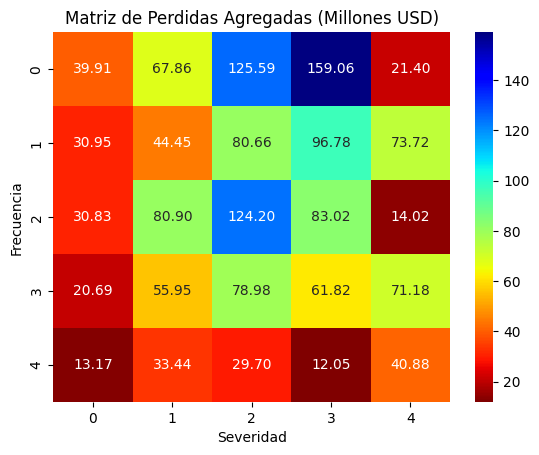

Perdida agregada total observada: 1491.17 Millones USD


In [ ]:
# Matriz de perdidas agregadas: numero de eventos x severidad promedio (Millones USD)
MELDA = MEf*MEs

plt.figure()
sns.heatmap(MELDA, annot=True, fmt='.2f', cmap='jet_r')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title('Matriz de Perdidas Agregadas (Millones USD)')
plt.show()

print("Perdida agregada total observada:", np.round(np.sum(MELDA),2), "Millones USD")

4. Construccion de la Matriz de Impacto y la Matriz de Gestion

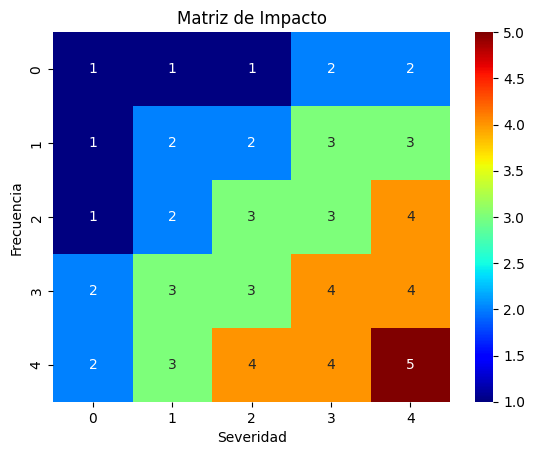

In [ ]:
# Matriz de impacto (estructura estandar de riesgo operacional)
MI = np.array([[1,1,1,2,2],
               [1,2,2,3,3],
               [1,2,3,3,4],
               [2,3,3,4,4],
               [2,3,4,4,5]])

plt.figure()
sns.heatmap(MI, annot=True, fmt='.0f', cmap='jet')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title('Matriz de Impacto')
plt.show()

# Matriz de gestion - involucra recursos de la organizacion
NG = np.int32(input("Ingresar el nivel de Gestion (1,2,3,4): "))
MG = np.copy(MI)
for i in range(5): # Si es mayor que 1 y menor que 5, incrementa la gestion
  for j in range(5):
    if MG[i,j] > 1 and MG[i,j] < 5:
      MG[i,j] = MG[i,j]*NG

plt.figure()
sns.heatmap(MG, annot=True, fmt='.0f', cmap='jet')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')
plt.title(f'Matriz de Gestion (Nivel {NG})')
plt.show()

5. Estimacion cuantitativa: Perdida Esperada (PE) y Operational Value at Risk (OpVaR) al 99,9%

Se calculan dos escenarios:
- **Riesgo Inherente (Perdidas No Gestionadas):** considera el impacto pero no aplica gestion.
- **Riesgo Residual (Perdidas Gestionadas):** aplica la matriz de gestion para reducir las perdidas.


In [ ]:
# 1. Perdida esperada simple (promedio del LDA diario)
PE_simple = np.mean(LDA)
print("Perdida Esperada simple (promedio diario):", np.round(PE_simple,3), "Millones USD")

# 2. Como no todos los eventos tienen la misma frecuencia, calculamos el promedio ponderado
PE_pond = np.round(np.sum(MEf*MEs)/np.sum(MEf),3)
print("Perdida Esperada ponderada por frecuencia:", PE_pond, "Millones USD")

# 3. Perdida Esperada considerando la matriz de impacto (Riesgo Inherente)
PE_inherente = np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("Perdida Esperada Inherente (con impacto):", np.round(PE_inherente,3), "Millones USD")

# 4. Perdida Esperada considerando la matriz de gestion (Riesgo Residual)
PE_residual = np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"Perdida Esperada Residual (con gestion {NG}):", np.round(PE_residual,3), "Millones USD")

In [ ]:
# Calculo del OpVaR al 99,9% de confianza
# Se utiliza el enfoque parametrico: OpVaR = PE + Z(99.9%) * sigma
# y tambien el enfoque empirico (percentil 99,9% de la distribucion de perdidas)

Z = stats.norm.ppf(0.999) # Z = 3.0902 para el 99,9% de confianza
print("Factor Z al 99,9% de confianza:", np.round(Z,4))

# --- Distribucion de perdidas Inherente: cada evento ponderado por su impacto ---
nf_idx = df['Nivel_f'].astype(int).values
ns_idx = df['Nivel_S'].astype(int).values
impacto_evento = MI[nf_idx, ns_idx]    # Nivel de impacto de cada evento
gestion_evento = MG[nf_idx, ns_idx]    # Nivel de gestion de cada evento

LDA_inherente = LDA*impacto_evento                    # Perdidas no gestionadas
LDA_residual  = LDA*impacto_evento/gestion_evento     # Perdidas gestionadas

# --- OpVaR Parametrico ---
OpVaR_inh_param = np.mean(LDA_inherente) + Z*np.std(LDA_inherente)
OpVaR_res_param = np.mean(LDA_residual) + Z*np.std(LDA_residual)

# --- OpVaR Empirico (percentil 99,9%) ---
OpVaR_inh_emp = np.percentile(LDA_inherente, 99.9)
OpVaR_res_emp = np.percentile(LDA_residual, 99.9)

# Resumen comparativo
resumen = pd.DataFrame({
    'Escenario': ['Riesgo Inherente (sin gestion)', f'Riesgo Residual (gestion {NG})'],
    'Perdida Esperada (PE)': [np.mean(LDA_inherente), np.mean(LDA_residual)],
    'Desviacion Estandar': [np.std(LDA_inherente), np.std(LDA_residual)],
    'OpVaR 99,9% Parametrico': [OpVaR_inh_param, OpVaR_res_param],
    'OpVaR 99,9% Empirico': [OpVaR_inh_emp, OpVaR_res_emp]
})
resumen_round = resumen.copy()
for c in resumen.columns[1:]:
    resumen_round[c] = resumen[c].round(3)
print("\nResumen comparativo (Millones USD):")
print(resumen_round.to_string(index=False))

# Reduccion porcentual del OpVaR gracias a la gestion
reduccion = (1 - OpVaR_res_param/OpVaR_inh_param)*100
print(f"\nLa gestion nivel {NG} reduce el OpVaR en {np.round(reduccion,2)} %")

In [ ]:
# Visualizacion comparativa de las distribuciones de perdidas
fig, axes = plt.subplots(1, 2, figsize=(13,4))

axes[0].hist(LDA_inherente, bins=40, color='crimson', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(LDA_inherente), color='black', linestyle='--', label='PE')
axes[0].axvline(OpVaR_inh_param, color='blue', linestyle='--', label='OpVaR 99,9%')
axes[0].set_title('Distribucion de Perdidas - Riesgo Inherente')
axes[0].set_xlabel('Perdida (Millones USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(LDA_residual, bins=40, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(LDA_residual), color='black', linestyle='--', label='PE')
axes[1].axvline(OpVaR_res_param, color='blue', linestyle='--', label='OpVaR 99,9%')
axes[1].set_title(f'Distribucion de Perdidas - Riesgo Residual (Gestion {NG})')
axes[1].set_xlabel('Perdida (Millones USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

6. Herramienta de Auditoria: Filtro Dinamico por celda de la Matriz de Perdidas

Esta funcion permite seleccionar cualquier celda (fila de Frecuencia, columna de Severidad) y desplegar el listado detallado de los eventos que la componen, junto con su descripcion.


In [ ]:
def consultar_celda(fila, columna):
    """
    Filtra los eventos de la base de datos que pertenecen a una celda
    especifica de la matriz de perdidas (fila = nivel de frecuencia,
    columna = nivel de severidad). Retorna un DataFrame con el detalle.
    """
    filtro = (df['Nivel_f'] == fila) & (df['Nivel_S'] == columna)
    eventos = df[filtro][['Fecha','Freq','Sev.','LDA','Descripcion']].copy()
    eventos.columns = ['Fecha','Trans. Fallidas','Severidad (M USD)','Perdida (M USD)','Descripcion del Evento']

    print(f"=== Celda [Frecuencia={fila}, Severidad={columna}] ===")
    print(f"Numero de eventos en la celda: {len(eventos)}")
    if len(eventos) > 0:
        print(f"Perdida total de la celda: {np.round(eventos['Perdida (M USD)'].sum(),2)} Millones USD")
        print(f"Severidad promedio: {np.round(eventos['Severidad (M USD)'].mean(),3)} Millones USD")
    return eventos

# Ejemplo de uso: consultar la celda mas critica (frecuencia alta, severidad alta)
print("\nEjemplo 1 - Celda [4,4] (Frecuencia y Severidad muy altas):")
detalle = consultar_celda(4,4)
detalle.head(10)

In [ ]:
# Ejemplo 2: consultar una celda de bajo impacto
print("\nEjemplo 2 - Celda [0,0] (Frecuencia y Severidad bajas):")
detalle2 = consultar_celda(0,0)
detalle2.head(10)

In [ ]:
# Filtro interactivo: el usuario ingresa la celda a consultar
fila_in = np.int32(input("Ingrese el nivel de Frecuencia (0-4): "))
col_in = np.int32(input("Ingrese el nivel de Severidad (0-4): "))
detalle_user = consultar_celda(fila_in, col_in)
detalle_user

**Analisis de Resultados**

La Pérdida Esperada simple (promedio diario) refleja el costo medio de los eventos de falla tecnológica sin ningún tipo de ponderación. Cuando se incorpora la matriz de impacto, la Pérdida Esperada Inherente aumenta porque los eventos catastróficos (aunque infrecuentes) reciben un peso mayor, lo que es coherente con la lógica de riesgo operacional: las pérdidas extremas son las que realmente comprometen la solvencia de la entidad financiera.

Al aplicar la matriz de gestión, la Pérdida Esperada Residual disminuye proporcionalmente al nivel de gestión (NG) seleccionado. Lo mismo ocurre con el OpVaR al 99,9%: el escenario residual presenta colas mucho menos pesadas, lo que demuestra que las inversiones en controles (monitoreo en tiempo real, planes de continuidad, ciberseguridad) reducen tanto la pérdida promedio como la pérdida en cola.

- **Matriz de impacto:** muestra el nivel de impacto financiero que tiene cada combinación de frecuencia y severidad sobre la entidad. Las celdas con valor 5 representan eventos catastróficos (caídas totales del sistema, ciberataques masivos) y son las que deben priorizarse en la asignación de recursos.
- **Matriz de gestión:** indica el esfuerzo de control que se debe asignar a cada celda de impacto. A mayor nivel de gestión, mayor es la inversión en controles (capacitación → monitoreo en tiempo real → DRP automatizado → ciberseguros), pero también mayor es la reducción de las pérdidas catastróficas. Esto es consistente con la lógica de Basel II/III sobre riesgo operacional, donde el OpVaR debe ser cubierto por capital económico, y donde la gestión activa permite liberar capital regulatorio.
- **Herramienta de auditoría:** el filtro dinámico permite a los auditores y al área de riesgo trazar cualquier celda de la matriz de pérdidas hasta los eventos individuales que la componen, facilitando la justificación ante reguladores y la priorización de planes de remediación.